# Amazon Sales Data Analysis

## Introduction

This project analyses an Amazon sales dataset to identify sales trends, product performance and category revenue. The analysis uses descriptive statistics and visualisations to identify patterns and provide business recommendations based on the available data.

In [5]:
import pandas as pd

df = pd.read_csv("/content/Amazon Sale Report.csv")

df.head()

/tmp/ipykernel_1825/1121612467.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
df.shape

(128975, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [ ]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
index,0.00
Order ID,0.00
Date,0.00
Status,0.00
Fulfilment,0.00
Sales Channel,0.00
ship-service-level,0.00
Style,0.00
SKU,0.00
Category,0.00


In [ ]:
df['Status'].value_counts()

,count
Status,
Shipped,77804
Shipped - Delivered to Buyer,28769
Cancelled,18332
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


In [ ]:
df[df['Amount'].isna()]['Status'].value_counts()

,count
Status,
Cancelled,7566
Shipped,208
Shipped - Delivered to Buyer,8
Shipping,8
Shipped - Returned to Seller,3
Pending,2


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Order ID'].duplicated().sum()

np.int64(8597)

In [ ]:
df[df['Order ID'].duplicated(keep=False)][
    ['Order ID', 'SKU', 'Category', 'Qty', 'Amount']
].head(20)

,Order ID,SKU,Category,Qty,Amount
37,403-4367956-2849158,JNE3787-KR-S,kurta,1,487.00
38,403-4367956-2849158,JNE3543-KR-S,kurta,1,368.00
61,404-2262140-4696366,JNE2270-KR-487-A-M,kurta,1,518.00
62,404-2262140-4696366,JNE3579-KR-M,kurta,1,295.00
79,408-4069830-3819562,SET288-KR-NP-XXXL,Set,1,684.00
80,408-4069830-3819562,SET394-KR-NP-XXXL,Set,1,1281.00
81,408-4069830-3819562,SET397-KR-NP-XXXL,Set,1,1186.00
105,405-5257740-5301158,SET154-KR-NP-XL,Set,1,832.00
106,405-5257740-5301158,JNE3439-KR-XL,kurta,1,399.00
116,403-0104882-7373900,JNE3861-DR-XXL,Western Dress,1,791.00


In [ ]:
df = df.drop(columns=['Unnamed: 22'])

KeyError: "['Unnamed: 22'] not found in axis"

In [ ]:
df.shape

(128975, 23)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

## Data Cleaning

The dataset was inspected for missing values, duplicate records and incorrect data types.

The following cleaning steps were performed:

- Removed the unnecessary `Unnamed: 22` column.
- Converted the `Date` column from text to a datetime format.
- Checked for completely duplicated rows; none were found.
- Duplicate Order IDs were retained because individual orders can contain multiple SKUs.
- Missing `Amount` values were retained rather than replacing them with estimated values.
- Zero `Amount` values were retained because some shipped and delivered records contained zero values.

In [ ]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Amount'].describe()

,Amount
count,121180.000000
mean,648.561465
std,281.211687
min,0.000000
25%,449.000000
50%,605.000000
75%,788.000000
max,5584.000000


In [ ]:
(df['Amount'] == 0).sum()

np.int64(2343)

In [ ]:
df[df['Amount'] == 0]['Status'].value_counts()

,count
Status,
Shipped,1518
Shipped - Delivered to Buyer,716
Shipped - Returned to Seller,51
Shipped - Picked Up,28
Pending,17
Pending - Waiting for Pick Up,9
Shipped - Lost in Transit,2
Shipped - Returning to Seller,2


In [ ]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by']

## Descriptive Statistics

In [ ]:
print("Mean:", df['Amount'].mean())
print("Median:", df['Amount'].median())
print("Mode:", df['Amount'].mode()[0])
print("Standard Deviation:", df['Amount'].std())

Mean: 648.5614647631621
Median: 605.0
Mode: 399.0
Standard Deviation: 281.21168722916195


## Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

monthly_sales

,Amount
Date,
2022-03,101683.85
2022-04,28838708.32
2022-05,26226476.75
2022-06,23425809.38


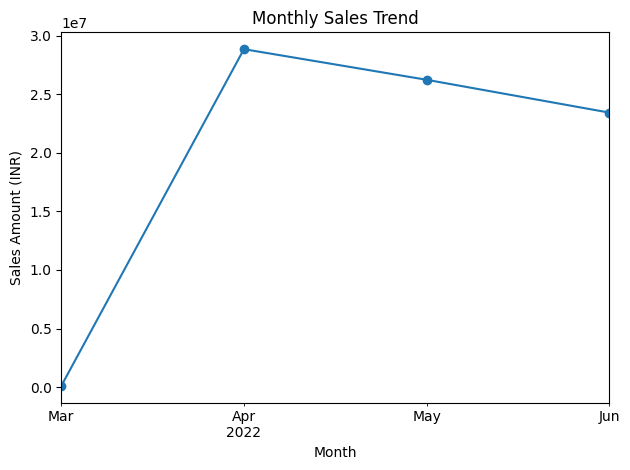

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Sales increased substantially from March to April 2022 and remained at a high level through May and June. April recorded the highest monthly sales among the four months shown, while March recorded substantially lower sales.

## Quarterly Sales Trend

In [ ]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Amount'].sum()

quarterly_sales

,Amount
Date,
2022Q1,101683.85
2022Q2,78490994.45


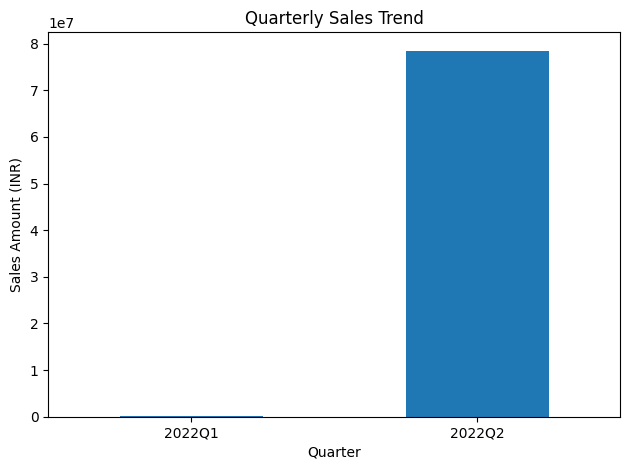

In [ ]:
quarterly_sales.plot(kind='bar')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Sales Amount (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The quarterly analysis shows a major increase in sales from Q1 to Q2 2022. Q2 generated substantially higher sales than Q1, indicating strong growth during the second quarter.

## Top 10 Products by Sales

In [ ]:
top_10_products = (
    df.groupby('SKU')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_10_products

,Amount
SKU,
J0230-SKD-M,527699.20
JNE3797-KR-L,524581.77
J0230-SKD-S,479937.14
JNE3797-KR-M,454290.16
JNE3797-KR-S,407302.57
JNE3797-KR-XL,332155.24
J0230-SKD-L,305616.95
JNE3797-KR-XS,303616.70
SET268-KR-NP-XL,284058.96


### Observation

The top 10 SKUs contribute a significant amount of sales, with J0230-SKD-M and JNE3797-KR-L recording the highest sales amounts among the products analysed. The results show that a relatively small group of SKUs accounts for a substantial share of product sales.

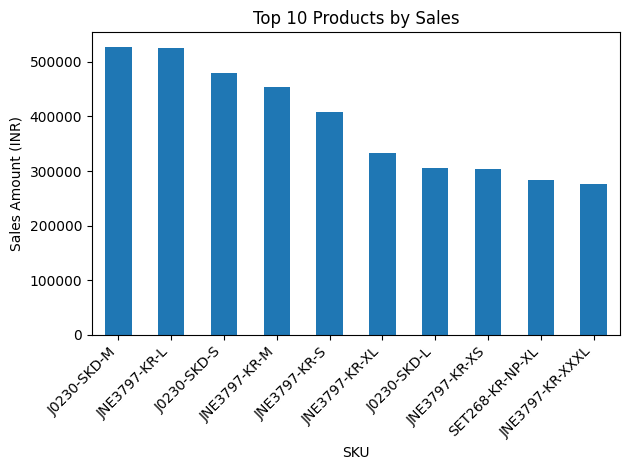

In [ ]:
top_10_products.plot(kind='bar')

plt.title('Top 10 Products by Sales')
plt.xlabel('SKU')
plt.ylabel('Sales Amount (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Revenue by Product Category

In [ ]:
category_revenue = (
    df.groupby('Category')['Amount']
      .sum()
      .sort_values(ascending=False)
)

category_revenue

,Amount
Category,
Set,39204124.03
kurta,21299546.70
Western Dress,11216072.69
Top,5347792.30
Ethnic Dress,791217.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00


### Observation

The Set category generated the highest revenue, followed by kurta and Western Dress. These three categories account for the majority of revenue, indicating that they are the strongest product categories in the dataset.

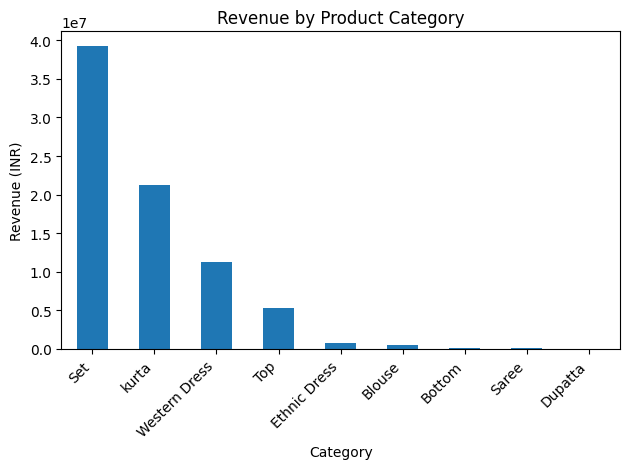

In [ ]:
category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Correlation Heatmap

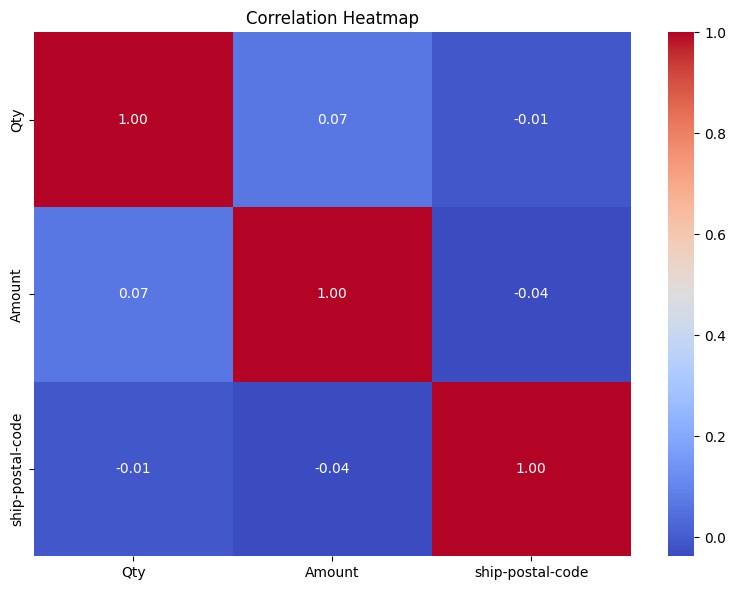

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = df[['Qty', 'Amount', 'ship-postal-code']]

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between quantity, sales amount and shipping postal code. Quantity and Amount show a relatively weak relationship, indicating that higher quantities do not necessarily correspond to proportionally higher sales amounts. Shipping postal code does not provide a meaningful business relationship with sales performance.

## Sales by Order Status

In [ ]:
status_sales = (
    df.groupby('Status')['Amount']
      .sum()
      .sort_values(ascending=False)
)

status_sales

,Amount
Status,
Shipped,50324255.0
Shipped - Delivered to Buyer,18650815.0
Cancelled,6919284.3
Shipped - Returned to Seller,1269644.0
Shipped - Picked Up,661252.0
Pending,430271.0
Pending - Waiting for Pick Up,192138.0
Shipped - Returning to Seller,107620.0
Shipped - Out for Delivery,26971.0


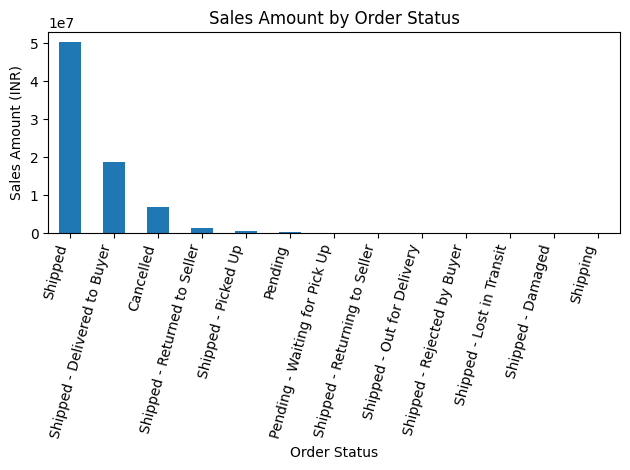

In [ ]:
status_sales.plot(kind='bar')

plt.title('Sales Amount by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Sales Amount (INR)')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

### Observation

Shipped orders generated the highest sales amount, followed by orders that were shipped and delivered to the buyer. Cancelled orders also represent a substantial amount of sales, highlighting the potential impact of cancellations on overall revenue.

## Key Findings

- Sales increased substantially from March to April 2022 and remained high through May and June.
- Q2 2022 generated substantially more revenue than Q1 2022.
- The top-performing SKUs were J0230-SKD-M and JNE3797-KR-L.
- The Set category generated the highest revenue, followed by kurta and Western Dress.
- Shipped orders generated the highest sales amount, while cancelled orders also represented a substantial amount of sales.
- The fulfilment analysis shows that sales were generated through both Amazon and Merchant fulfilment methods.
- The dataset does not contain customer age or gender variables, so demographic analysis could not be performed.

## Business Recommendations

1. **Prioritise high-performing products:** Focus inventory, marketing and promotional efforts on the highest-performing SKUs, particularly J0230-SKD-M and JNE3797-KR-L, while maintaining sufficient stock to meet demand.

2. **Focus on the strongest categories:** The Set, kurta and Western Dress categories generate the largest amounts of revenue. The business should prioritise these categories when planning inventory and future promotions.

3. **Reduce the impact of cancellations:** Cancelled orders represent a substantial amount of sales. The business should investigate the main causes of cancellations and improve stock availability, order processing and fulfilment where possible.

## Conclusion

The analysis of the Amazon Sales Report identified clear differences in sales performance across time periods, products, categories and order statuses. Sales increased significantly during Q2 2022, while the Set, kurta and Western Dress categories generated the highest revenue.

The analysis also identified a small group of high-performing SKUs that contribute strongly to sales. At the same time, cancelled orders represent a significant amount of sales and should be investigated to reduce potential revenue loss.

Overall, the findings can help the business improve inventory planning, focus marketing efforts on high-performing products and categories, and investigate operational factors contributing to cancellations.

A limitation of the dataset is that it does not contain customer age or gender information, so demographic analysis could not be performed.

In [6]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

## Customer Demographics

The task requirements include an analysis of customer age groups and gender. However, the Amazon Sales Report dataset does not contain age or gender variables. Therefore, customer age and gender analysis cannot be performed using this dataset without introducing external data.

This limitation is documented rather than estimating or fabricating demographic information.

<Axes: title={'center': 'Sales by Fulfilment Method'}, xlabel='Fulfilment Method', ylabel='Total Sales'>

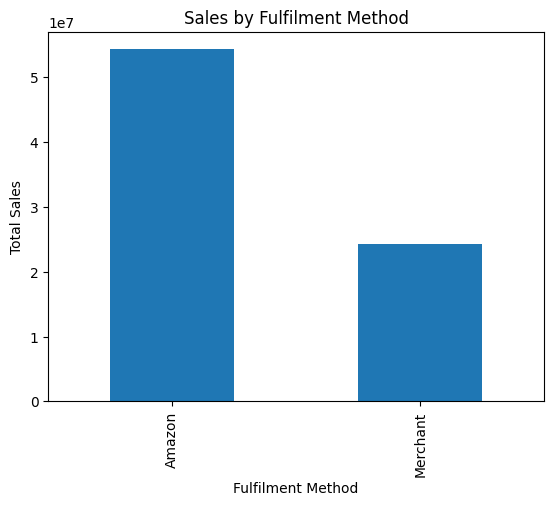

In [7]:
fulfilment_sales = (
    df.groupby('Fulfilment')['Amount']
      .sum()
      .sort_values(ascending=False)
)

fulfilment_sales.plot(
    kind='bar',
    title='Sales by Fulfilment Method',
    xlabel='Fulfilment Method',
    ylabel='Total Sales'
)

### Observation

The chart shows that sales are generated through different fulfilment methods, allowing the business to compare their contribution to overall sales. The difference between fulfilment methods can help identify which fulfilment approach is associated with stronger sales performance and may help guide future operational planning.